# Solow Model

Pablo Winant

> **Prerequisites**
>
> This tutorial refers to the lecture on the [convergence of
> sequences](../lectures/convergence/).
>
> Also, make sure you went through the [Julia
> Basics](./Julia_Basics.qmd) before.

# Tutorial: Convergence

### Solow Model

A representative agent uses capital $k_t$ to produce $y_t$ using the
following production function:

$$y_t = k_t^{\alpha}$$

He chooses to consume an amount $c_t \in ]0, y_t]$ and invests what
remains:

$$i_t = y_t - c_t$$

He accumulates capital $k_t$ according to:

$$k_{t+1} = \left( 1-\delta \right) k_{t} + i_{t}$$

where $\delta$ is the depreciation rate and $i_t$ is the amount
invested.

The goal of the representative agent is to maximize:

$$\sum_{t\geq 0} \beta^t U(c_t)$$

where $U(x)=\frac{x^{1-\gamma}}{1-\gamma}$ and $\beta<1$ is the discount
factor.

For now, we ignore the objective and assume that the saving rate
$s=\frac{c_t}{y_t}$ is constant over time.

**Create a `NamedTuple` to hold parameter values $\beta=0.96$,
$\delta=0.1$, $\alpha=0.3$, $\gamma=4$.**

In [2]:
model = (; # named arguments are introduced by ;
    α=0.3,
    β=0.96,
    γ=4,
    δ=0.1,
    s=0.2
)

(α = 0.3, β = 0.96, γ = 4, δ = 0.1, s = 0.2)

**Write down the formula of function $f$ such that $k_{t+1}$:
$k_{t+1} = f(k_t)$.**

$k_{t+1} = (1-\delta) k_{t} + s k_t^{\alpha}$

**Define a function `f(k::Float64, p::NamedTuple)::Float64` to represent
$f$ for a given calibration**

In [43]:
function f(k, model)
    # named argument unpacking
    (;s,α,δ) = model
    y = k^α
    i = s*y
    K = k*(1-δ) + i
    return K
end

f (generic function with 1 method)

In [4]:
@time f(1.0, model)

  0.003215 seconds (3.10 k allocations: 150.469 KiB, 99.48% compilation time)


1.1

**Write a function
`simulate(k0::Float64, T::Int, p::NamedTuple)::Vector{Float64}` to
compute the simulation over `T` periods starting from initial capital
level `k0`.**

In [44]:
# without preallocation: grow the vector as we go
function simulate(k0, T, p)
    res = [k0]
    for t=1:T
        k = res[end] # last element
        K = f(k, p)
        push!(res, K)   # exclamation mark: arguments are mutated (/modified)
    end
    return res
end

simulate (generic function with 1 method)

In [45]:
@time simulate(1.0, 40, model)

  0.009291 seconds (8.78 k allocations: 428.477 KiB, 99.78% compilation time)


41-element Vector{Float64}:
 1.0
 1.1
 1.195801151884219
 1.2872430129191352
 1.3742574618933996
 1.456845771393547
 1.5350611815735393
 1.6089955116075123
 1.6787687913320717
 1.7445211874595348
 ⋮
 2.5033478018377444
 2.516395180668215
 2.528548894721841
 2.539868814478072
 2.550410988577142
 2.5602278602378736
 2.5693684756833584
 2.577878684115585
 2.5858013289604305

In [46]:
# with preallocation
function simulate(k0, T, p)
    res = zeros(T+1)
    res[1] = k0
    # k = k0
    for t=1:T
        K = f(k0, p)
        k0 = K
        res[t+1] = K   
    end
    return res
end

simulate (generic function with 1 method)

In [47]:
@time simulate(1.0, 40, model)

  0.008462 seconds (8.00 k allocations: 402.836 KiB, 99.76% compilation time)


41-element Vector{Float64}:
 1.0
 1.1
 1.195801151884219
 1.2872430129191352
 1.3742574618933996
 1.456845771393547
 1.5350611815735393
 1.6089955116075123
 1.6787687913320717
 1.7445211874595348
 ⋮
 2.5033478018377444
 2.516395180668215
 2.528548894721841
 2.539868814478072
 2.550410988577142
 2.5602278602378736
 2.5693684756833584
 2.577878684115585
 2.5858013289604305

**Make a nice plot to illustrate the convergence. Do we get convergence
from any initial level of capital?**

In [10]:
using Plots

In [48]:
sim = simulate(1.0, 40, model) ; 

In [12]:
using LaTeXStrings

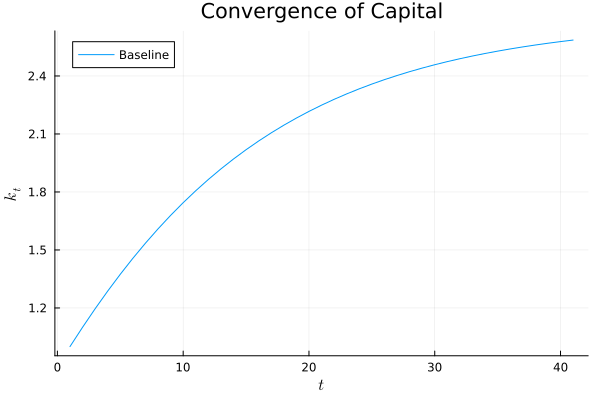

In [49]:
plot(sim, 
    title="Convergence of Capital",
    xlabel=L"t",
    ylabel=L"k_t",
    label="Baseline"
)

In [14]:
# different levels of capital

In [50]:
k0_vec = [0.5, 1.0, 1.5, 2.0]
# vector comprehension
sims = [ simulate(k, 100, model) for k in k0_vec]

4-element Vector{Vector{Float64}}:
 [0.5, 0.6124504792712471, 0.7238493517042889, 0.832984403877418, 0.9390166705127817, 1.041375090175603, 1.139684956743144, 1.233717469453318, 1.3233531316502873, 1.40855461086888  …  2.688124717954504, 2.688381961924404, 2.688621205942895, 2.6888437090435797, 2.6890506422578495, 2.68924309475745, 2.6894220795694443, 2.689588538893184, 2.689743349046873, 2.6898873250694084]
 [1.0, 1.1, 1.195801151884219, 1.2872430129191352, 1.3742574618933996, 1.456845771393547, 1.5350611815735393, 1.6089955116075123, 1.6787687913320717, 1.7445211874595348  …  2.689166098397878, 2.689350471394512, 2.6895219419408285, 2.689681412713881, 2.689829723270148, 2.6899676544549416, 2.6900959325043807, 2.69021523286128, 2.6903261837248396, 2.6904293693526475]
 [1.5, 1.5758693870913711, 1.6475201583781263, 1.7150841935587584, 1.7787098808849766, 1.8385565989758454, 1.8947904001991414, 1.9475806400433953, 1.9970973557459901, 2.0435092411105487  …  2.690038701794708, 2.6901620075

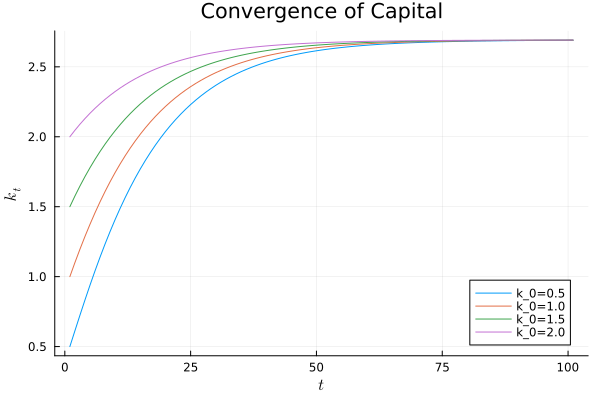

In [51]:
# keep a name for the graph
pl = plot(
    title="Convergence of Capital",
    xlabel=L"t",
    ylabel=L"k_t",
    label="Baseline"
)
# # ! modify the graph
# plot!(pl, sims[1])
# plot!(pl, sims[2])
# plot!(pl, sims[3])
# i = 0
# for sim in sims
#     i += 1
#     k0 = k0_vec[i]
#     plot!(pl, sim, label="k_0=$k0")
# end
for (k0, sim) in zip(k0_vec, sims)
    plot!(pl, sim, label="k_0=$k0")
end
pl

In [52]:
merge(model,
(;s=0.1)
)

(α = 0.3, β = 0.96, γ = 4, δ = 0.1, s = 0.1)

In [53]:
# what is the effect of saving?
sim = simulate(1.5, 100, model)
sim_low = simulate(1.5, 100, merge(model, (;s=0.3)))   # savings are lower
sim_high = simulate(1.5, 100, merge(model, (;s=0.8)))   # savings are higher

101-element Vector{Float64}:
  1.5
  2.2534775483654848
  3.0489422423682484
  3.8617724554365838
  4.6754425447097425
  5.478580074918608
  6.263293169816151
  7.0241374343029905
  7.757437531507819
  8.46082080676875
  ⋮
 19.474073941569166
 19.47618356874936
 19.478145588185654
 19.479970323479897
 19.481667376790046
 19.483245679167947
 19.484713537395507
 19.48607867756146
 19.48734828560424

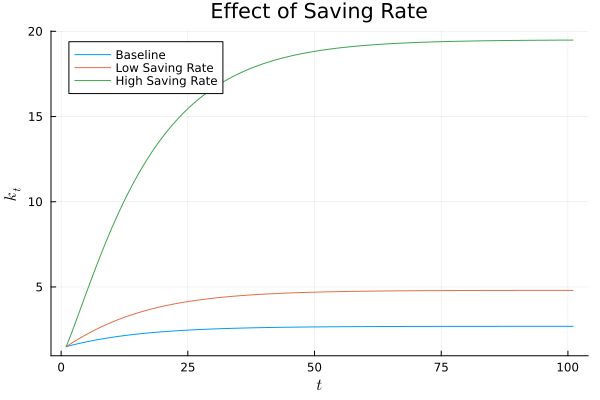

In [54]:
pl = plot(
    title="Effect of Saving Rate",
    xlabel=L"t",
    ylabel=L"k_t",
    label="Baseline"
)
plot!(sim; label="Baseline")
plot!(sim_low; label="Low Saving Rate")
plot!(sim_high; label="High Saving Rate")

In [55]:
methods(range)

# 6 methods for generic function "range" from Base:
 [1] range(; start, stop, length, step)
     @ range.jl:160
 [2] range(start::T, stop::T; kwargs...) where T<:Colorant
     @ ~/.julia/packages/Colors/VFEJ1/src/utilities.jl:554
 [3] range(start, stop; length, step)
     @ range.jl:157
 [4] range(start::T; stop, length) where T<:Colorant
     @ ~/.julia/packages/Colors/VFEJ1/src/utilities.jl:549
 [5] range(start; stop, length, step)
     @ range.jl:155
 [6] range(start, stop, length::Integer)
     @ range.jl:158

In [29]:
range(; start=0.1, stop=0.3, length=10)

0.1:0.022222222222222223:0.3

In [56]:
saving_rates =  range(0.1, 0.9, 100)
steady_states = [simulate(1.5, 1000, merge(model, (;s=s_)))[end] for s_ ∈ saving_rates]

100-element Vector{Float64}:
  1.0000000000000027
  1.1174092484344746
  1.2386443808299643
  1.3635507600087418
  1.4919898156842462
  1.6238364801989473
  1.758977159823149
  1.8973081062670476
  2.038734092584153
  2.1831673242267398
  ⋮
 20.747109199199468
 21.034413215419605
 21.322899362573853
 21.61256121694328
 21.90339244989956
 22.195386825622972
 22.488538198895885
 22.782840512968423
 23.0782877974931

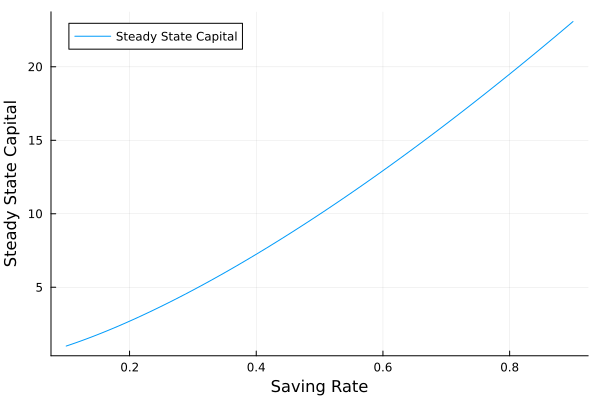

In [57]:
plot(saving_rates, steady_states, label="Steady State Capital", xlabel="Saving Rate", ylabel="Steady State Capital")

In [64]:
[1,2,3] .* [1,2,3]

3-element Vector{Int64}:
 1
 4
 9

In [ ]:
#[]

In [ ]:
(;α, β, γ, s) = model
ysim = sim .^ α
csim = ysim*(1-s)
usim = csim .^ (1-γ) ./ (1-γ)
bsim = β.^(0:(length(sim)-1))
sum(bsim .* usim)


sum( [ β^t*(sim[t+1]^α*(1-s))^(1-γ)/ (1-γ) for t in 0:(length(sim)-1) ])

-8.010122187895862

In [81]:
γ

4

In [89]:
function welfare(sim, model)
    (;α, β, γ, s) = model

    # sim ocntains capital valuesa
    sum( [ β^t*(sim[t+1]^α*(1-s))^(1-γ)/ (1-γ) for t in 0:(length(sim)-1) ])
end

welfare (generic function with 1 method)

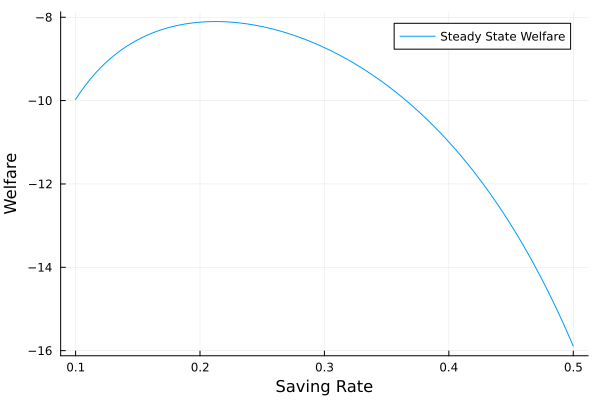

In [94]:
saving_rates =  range(0.1, 0.5, 100)
welfares = [
    let 
        new_model = merge(model, (;s=s_))
        sim = simulate(1.5, 1000, new_model)
        welfare(sim, new_model)
    end
    for s_ ∈ saving_rates
]
plot(saving_rates, welfares, label="Steady State Welfare", xlabel="Saving Rate", ylabel="Welfare")

**Suppose you were interested in using `f` to compute the steady-state.
What would you propose to measure convergence speed? To speed-up
convergence? Implement these ideas.**